# BEE 4750 Lab 1: Convergence and Discretization

**Name**:

**ID**:

> **Due Date**
>
> TBD

## Setup

In [13]:
import Pkg
Pkg.activate(".")
Pkg.instantiate()

  Activating project at `/content`


In [14]:
using Plots
using LaTeXStrings

## Introduction

In lecture, we discretized a first-order ODE with **forward Euler** and
used a **convergence study** (halve $\Delta t$, watch a quantity of
interest, plot error against $\Delta t$ on log-log axes) to decide
whether a step size was small enough. We did this for a box model of an
airshed, where the pollutant concentration $C(t)$ satisfied

$$\frac{dC}{dt} = P(t) - lC(t),$$

with $P(t)$ a (possibly time-varying) source term and $l$ a first-order
loss rate. Once $P(t)$ varied in time, there was no closed-form
solution, so we built a trustworthy “truth” by running forward Euler at
a very fine $\Delta t$, and checked coarser $\Delta t$ against it.

This lab applies exactly that workflow to a new setting: a **landfill
gas generation model**. If you get stuck on the numerics, it’s worth
pulling up that lecture’s code side-by-side with this notebook.

### The Model

Landfilled waste decomposes and generates gas (mostly CH<sub>4</sub> and
CO<sub>2</sub>) at a rate that responds, with some lag, to how much
waste is currently in place. We’ll model the landfill gas generation
rate $G(t)$ with

$$\frac{dG}{dt} = k\left(L_0 \, W(t) - G(t)\right),$$

| Symbol | Meaning | Units |
|:--:|:---|:---|
| $G(t)$ | landfill gas generation rate (the state) | m<sup>3</sup> CH<sub>4</sub>/yr |
| $W(t)$ | waste acceptance rate | Mg/yr |
| $L_0$ | methane generation potential per unit waste | m<sup>3</sup> CH<sub>4</sub>/Mg |
| $k$ | first-order decay/generation-response rate | 1/yr |

This has the same structure as the airshed model from lecture: a source
term driving the state up, and a first-order loss term (here, $-kG$)
pulling it back down, so that $G(t)$ tracks $L_0 W(t)$ with a lag set by
$k$.

We’ll use the following scenario: a landfill accepts waste at a constant
rate $W_\text{max}$ for a 20-year active life, then closes (waste
acceptance drops to zero), and we track gas generation for another 20
years after that ($T = 40$ yr total).

In [15]:
landfill_params = let
    k = 0.15            # first-order decay/generation-response rate  [1/yr]
    L0 = 100.0          # methane generation potential                [m³ CH₄ / Mg]
    Wmax = 1.0e5        # waste acceptance rate while open             [Mg/yr]
    active_life = 20.0  # years the landfill accepts waste             [yr]
    (; k, L0, Wmax, active_life)
end

T_total = 40.0   # total simulation horizon [yr]
G0 = 0.0         # initial gas generation rate [m³ CH₄/yr]

# Waste acceptance rate: constant while the landfill is open, zero after closure.
waste_rate(t, p) = t < p.active_life ? p.Wmax : 0.0

waste_rate (generic function with 1 method)

> **Two Ways to Work Through This Lab**
>
> You can do the coding either in this notebook (`lab01.ipynb`) or in
> the plain script `lab01.jl`, whichever you prefer — both contain the
> same problems. Either way, the written/derivation parts (marked below)
> go on the separate **Activity Sheet** (handed out in class), which
> you’ll hand in or submit by the end of the day to Gradescope.

## Problem 1: Discretize and Implement

Before writing any code, complete Problem 1 on the Activity Sheet:
derive the forward Euler update for this model by hand, starting from
$\frac{dG}{dt} = k(L_0 W(t) - G(t))$.

Then complete the skeleton below, using your derivation.
`landfill_gas_rate` should return $dG/dt$ given the current state, time,
and parameters; you shouldn’t need to change it. The one line you need
to fill in is the forward Euler update inside `landfill_gas_simulate`,
using your derivation from Problem 1.

In [16]:
landfill_gas_rate(G, t, p) = p.k * (p.L0 * waste_rate(t, p) - G)

function landfill_gas_simulate(G_ic, T, Δt, p)
    steps = Int(round(T / Δt))
    G = zeros(steps + 1)   # index 1 holds the initial condition
    G[1] = G_ic
    for i in 1:steps
        t = (i - 1) * Δt
        # TODO: fill in the forward Euler update from Problem 1
        G[i+1] = G[i] + Δt * landfill_gas_rate(G[i], t, p)
    end
    return G
end

landfill_gas_simulate (generic function with 1 method)

Sanity-check your implementation by running it at a moderate step size
and plotting $G(t)$ over the full 40-year horizon. Does the shape make
sense (rising while the landfill is open, declining after closure)?

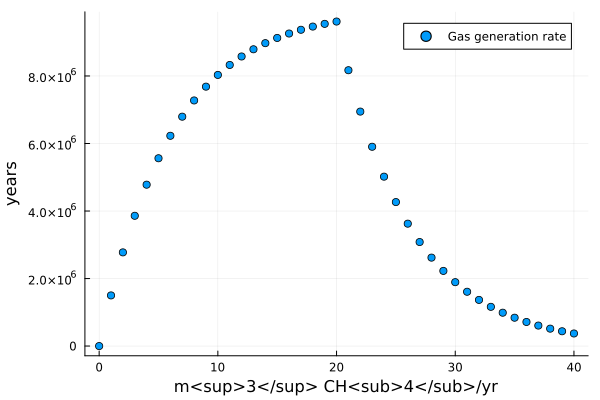

In [19]:
# insert your sanity-check simulation and plot here
forEuler = landfill_gas_simulate(G0, T_total, 1.0, landfill_params)
scatter(collect(0:40), forEuler, label="Gas generation rate")
xlabel!("m<sup>3</sup> CH<sub>4</sub>/yr")
ylabel!("years")

## Problem 2: How Small Does $\Delta t$ Need to Be?

Before running anything, complete Problem 2 on the Activity Sheet:
compute the model’s characteristic timescale, $1/|\text{rate}|$, and use
it to propose a starting $\Delta t$ that should be “well inside” it.

Now check that prediction empirically. Build a reference solution at a
very fine step size (finer than anything you’ll test), and use the peak
gas generation rate, $\max_t G(t)$, as your quantity of interest — this
is the number you’d use to size flare or collection-system capacity.

In [ ]:
Δt_ref = 0 # replace this with a very fine reference value
G_ref = landfill_gas_simulate(G0, T_total, Δt_ref, landfill_params)
peak_ref = maximum(G_ref)

Choose your **own** sequence of step sizes to test, starting from
wherever your Problem 2a estimate suggested and successively halving.
For each, compute the peak gas generation rate and its error relative to
the reference. Then make a log-log plot of error vs. $\Delta t$ (include
a reference line of slope 1, as in lecture, to compare against).

In [ ]:
# TODO: choose your own step sizes here (successively halved)
Δts = []

# TODO: compute the peak G at each Δt, and the error against peak_ref

# TODO: make the log-log convergence plot

Estimate the relative error improvement between successive step-size
refinements (: $\log_2(\text{err}_i / \text{err}_{i+1})$).

In [ ]:
# TODO: compute empirical orders between successive Δts

Transcribe your Δt sequence, peak values, errors, and empirical orders
into Table 1 on the Activity Sheet, then answer the interpretation
question there (is this consistent with forward Euler being first order,
and why).

## Problem 3: Make and Justify a Recommendation

Complete Problem 3 on the Activity Sheet: a short written recommendation
for what $\Delta t$ you’d actually use to size a flare system from this
model, justified using both the characteristic timescale and your
empirical convergence check.